Using device: cpu
Starting GAN training...

Batch 200 | Loss D: 1.2699 | Loss G: 2.1171
Batch 400 | Loss D: 0.7339 | Loss G: 1.9115
Batch 600 | Loss D: 1.0201 | Loss G: 1.7617
Batch 800 | Loss D: 0.7947 | Loss G: 1.5969

Generating Images...


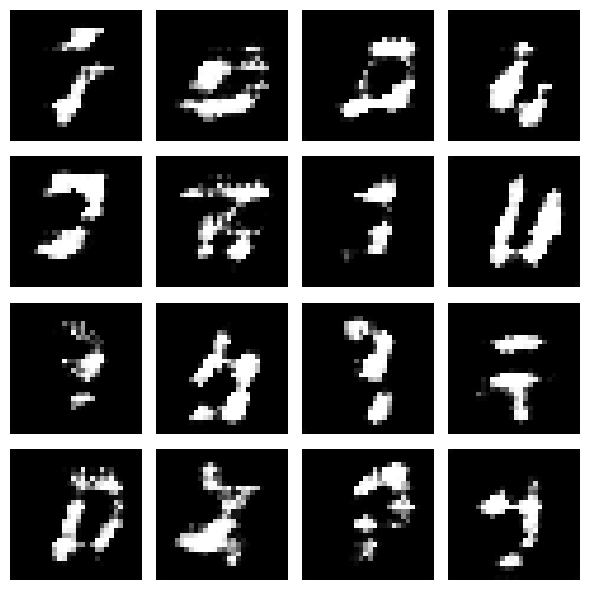


GAN Training Complete!


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

latent_dim = 100
img_size = 28
num_epochs = 1
batch_size = 64
lr = 0.0002

os.makedirs("generated_images", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

gen = Generator(latent_dim).to(device)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)

disc = Discriminator().to(device)

criterion = nn.BCELoss()
gen_optimizer = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

print("Starting GAN training...\n")

for epoch in range(num_epochs):
    for i, (imgs, _) in enumerate(dataloader):

        imgs = imgs.to(device)
        batch_size_curr = imgs.size(0)

        real_labels = torch.ones(batch_size_curr, 1).to(device)
        fake_labels = torch.zeros(batch_size_curr, 1).to(device)

        disc_optimizer.zero_grad()

        output_real = disc(imgs)
        loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = gen(noise)

        output_fake = disc(fake_imgs.detach())
        loss_fake = criterion(output_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        disc_optimizer.step()

        gen_optimizer.zero_grad()

        output = disc(fake_imgs)
        loss_G = criterion(output, real_labels)

        loss_G.backward()
        gen_optimizer.step()

        if (i + 1) % 200 == 0:
            print(f"Batch {i+1} | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

    print("\nGenerating Images...")

    gen.eval()
    with torch.no_grad():
        noise = torch.randn(16, latent_dim).to(device)
        samples = gen(noise).cpu()
        samples = (samples + 1) / 2

        fig, axes = plt.subplots(4, 4, figsize=(6, 6))
        for r in range(4):
            for c in range(4):
                axes[r, c].imshow(samples[r*4+c].squeeze(), cmap='gray')
                axes[r, c].axis('off')

        plt.tight_layout()
        plt.savefig("generated_images/output_epoch1.png")
        plt.show()

    gen.train()

print("\nGAN Training Complete!")